# Code for the empirical analysis in the paper 'Growth and Fund Structures'
### Constantinos Kardaras; Hyeng Keun Koo; Johannes Ruf
### August 2026

To run this code, the user must have access to WRDS, along with the Python package `wrds`.  For more details on WRDS and how to interact with WRDS, see the course notes on https://github.com/johruf/CRSP_on_WRDS_introduction.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import wrds   # needs to be installed, e.g. via pip

In [2]:
WRDS_LOGIN = 'xxx'    # update to your login info on WRDS

## Getting data

In [3]:
def load_data():
    """Load market and risk-free daily returns from WRDS."""
    with wrds.Connection(wrds_username=WRDS_LOGIN) as db:
        df_idx = db.raw_sql(
            "SELECT caldt AS date, vwretd, totcnt FROM crsp.dsp500_v2",
            date_cols='date').set_index('date')

        df_rf = db.raw_sql(
            "SELECT date, rf FROM ff.factors_daily",
            date_cols='date').set_index('date')
        
    return df_idx, df_rf


df_idx, df_rf = load_data()

Loading library list...
Done


`vwretd` corresponds to CRSP's Value-Weighted Return Index (which reinvests dividends).

`rf` is from the Fama-French data, and uses 1M treasury rates. Data are only available beginning July 1st, 1926.

In [4]:
df_idx.head()

,vwretd,totcnt
date,,
1925-12-31,NaN,89
1926-01-02,0.004297,89
1926-01-04,-0.001357,89
1926-01-05,-0.004603,89
1926-01-06,0.000537,89


In [5]:
df_rf.head()

,rf
date,
1926-07-01,0.0001
1926-07-02,0.0001
1926-07-06,0.0001
1926-07-07,0.0001
1926-07-08,0.0001


In [6]:
# Getting rid of data that were not available at the time when the paper was written
CUTOFF_DATE = '2025-12-31'

In [7]:
df = df_idx.join(df_rf, how='inner').loc[:CUTOFF_DATE].copy()

# Exact daily discounted simple return
df['disc_ret'] = (1 + df['vwretd']) / (1 + df['rf']) - 1

# Discounted market wealth and daily empirical counterparts of the continuous-time processes R and C
df['W_disc'] = (1 + df['disc_ret']).cumprod()
df['R'] = df['disc_ret'].cumsum()
df['C'] = (df['disc_ret']**2).cumsum()

In [8]:
df.head(3)

,vwretd,totcnt,rf,disc_ret,W_disc,R,C
date,,,,,,,
1926-07-01,0.002716,89,0.0001,0.002616,1.002616,0.002616,0.000007
1926-07-02,0.004275,89,0.0001,0.004175,1.006801,0.006790,0.000024
1926-07-06,0.000781,89,0.0001,0.000681,1.007487,0.007471,0.000025


In [9]:
df.tail(3)

,vwretd,totcnt,rf,disc_ret,W_disc,R,C
date,,,,,,,
2025-12-29,-0.003518,503,0.0002,-0.003717,806.065412,8.406099,3.424148
2025-12-30,-0.001398,503,0.0002,-0.001598,804.777577,8.404502,3.424151
2025-12-31,-0.007304,503,0.0002,-0.007502,798.739733,8.396999,3.424207


## Auxiliary functions

In [10]:
def shrinkage_factor(nuhat, C):
    """
    Calculate shrinkage factor for one-fund model.
    """
    def shrink(x):
        tmp = np.sqrt(1 + x) + np.sqrt(x)
        return 1 - 3 / (1 + tmp**(2/3) + tmp**(-2/3))

    ψ = 27 / 8 * nuhat**2 * C
    return shrink(ψ)

In [11]:
def plot_panel(df, start_of_plot=0, ttitle='', filename=''):
    # Keep the information accumulated since July 1926,
    # but display/trade only from start_of_plot onward
    R = df['R'].iloc[start_of_plot:]
    C = df['C'].iloc[start_of_plot:]
    r = df['disc_ret'].iloc[start_of_plot:]

    nuhat = R / C
    sf = shrinkage_factor(nuhat, C)

    # Position chosen at date t is held over the following return
    pi_unshrunk = nuhat.shift(1).fillna(0)
    pi_shrunk = (nuhat * sf).shift(1).fillna(0)

    # Exact discounted wealth, normalised to one at first displayed date
    W_nuhat = (1 + r * pi_unshrunk).cumprod()
    W_nuhat_s = (1 + r * pi_shrunk).cumprod()
    W_disc = df['W_disc'].iloc[start_of_plot:] / df['W_disc'].iloc[start_of_plot]

    # Discrete approximation to maximal F-achievable growth
    F = 0.5 * (r**2 * pi_unshrunk**2).cumsum()

    fig, ax = plt.subplots(2, 2, figsize=(15, 12))

    ax[0, 0].plot(nuhat, 'b', label=r"$\hat{\theta}$", linewidth=1.5)
    ax[0, 0].plot(nuhat * sf, 'r', label=r"$a \hat{\theta}$", linewidth=1.5)
    ax[0, 0].set_title(r'Estimate of $\hat{\theta}$ in the Bayesian setting')
    ax[0, 0].legend(frameon=False)

    ax[1, 0].plot(sf, 'r', label=r"$a$", linewidth=1.5)
    ax[1, 0].set_title(r'Shrinkage factor $a$')
    ax[1, 0].legend(frameon=False)

    ax[0, 1].plot(np.log(W_nuhat), 'b', linewidth=1.5, label=r'Log-wealth, using $\hat{\theta}$')
    ax[0, 1].plot(np.log(W_nuhat_s), 'r', linewidth=1.5, label=r'Log-wealth, using $a \hat{\theta}$')
    ax[0, 1].plot(np.log(W_disc), 'k', linewidth=1.5, label=r'Log-market portfolio')
    ax[0, 1].plot(F, 'g', linewidth=1.5, label=r'Maximal $\mathcal{F}$-achievable growth $F$')
    ax[0, 1].set_title('Logarithm of wealth processes')
    ax[0, 1].legend(frameon=False, fontsize=9)

    ax[1, 1].plot(C, 'm', linewidth=1.5, label=r'$C_{ww}$')
    ax[1, 1].set_title(r'Integrated variance $C_{ww}$')
    ax[1, 1].legend(frameon=False)

    plt.suptitle(ttitle, fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if filename:
        import os
        os.makedirs('plots', exist_ok=True)
        fig.savefig(f'plots/{filename}.png')
        print(f"Plot saved as plots/{filename}.png")

In [12]:
def performance_statistics(df, start_of_plot=0):
    """
    Calculate performance statistics for the market, unshrunk,
    and shrunk portfolios.

    Returns and wealth are discounted unless stated otherwise.
    The nominal CAGR converts discounted wealth back to nominal wealth.
    Turnover is one-way turnover, accounting for the drift in the
    market exposure before rebalancing.
    """
    # Estimator and shrinkage factor
    R = df['R'].iloc[start_of_plot:]
    C = df['C'].iloc[start_of_plot:]

    nuhat = R / C
    sf = shrinkage_factor(nuhat, C)

    # Target market exposures
    pi = pd.DataFrame({
        r'Market': 1.0,
        r'Unshrunk': nuhat,
        r'Shrunk': nuhat * sf,
    }, index=nuhat.index)

    # The exposure chosen at t-1 is applied to the return at t
    r = df['disc_ret'].loc[pi.index]
    held = pi.shift(1).iloc[1:]
    r = r.iloc[1:]

    returns = held.mul(r, axis=0)

    # Discounted wealth, normalised to one at the start of trading
    initial_wealth = pd.DataFrame([np.ones(len(returns.columns))], index=[pi.index[0]], columns=returns.columns)
    wealth = pd.concat([initial_wealth, (1 + returns).cumprod()])

    years = (wealth.index[-1] - wealth.index[0]).days / 365.25

    # Convert discounted wealth back to nominal wealth
    rf_wealth = (1 + df['rf'].loc[wealth.index]).cumprod()
    rf_wealth /= rf_wealth.iloc[0]
    wealth_nominal = wealth.mul(rf_wealth, axis=0)

    # One-way turnover: amount traded in the market portfolio when
    # rebalancing from the post-return exposure to the new target
    pre_trade = held.mul(1 + r, axis=0) / (1 + held.mul(r, axis=0))
    turnover = (pi.loc[returns.index] - pre_trade).abs()

    # Daily approximation to maximal F-achievable growth
    F_terminal = 0.5 * (returns['Unshrunk']**2).sum()

    result = pd.DataFrame({
        r'Annualised discounted log growth, $T^{-1}\log X_\pi(T)$, (%)': 100 * np.log(wealth.iloc[-1]) / years,
        'Nominal CAGR (%)': 100 * (wealth_nominal.iloc[-1]**(1 / years) - 1),
        'Annualised volatility (%)': 100 * returns.std(ddof=1) * np.sqrt(252),
        'Sharpe ratio': returns.mean() / returns.std(ddof=1) * np.sqrt(252),
        'Maximum drawdown of discounted wealth (%)': 100 * (wealth / wealth.cummax() - 1).min(),
        r'Terminal discounted wealth, $X_\pi(T)$': wealth.iloc[-1],
        'Mean absolute market exposure': held.abs().mean(),
        'Annualised one-way turnover (%)': 100 * turnover.mean() * 252,
        r'Terminal log wealth minus $F$, $\log X_\pi(T)-F(T)$': np.log(wealth.iloc[-1]) - F_terminal,
    }).T

    return result

## Empirical results reported in the paper

In [13]:
idx_start = 1000  
df.index[idx_start]

Timestamp('1929-11-12 00:00:00')

Plot saved as plots/US.png


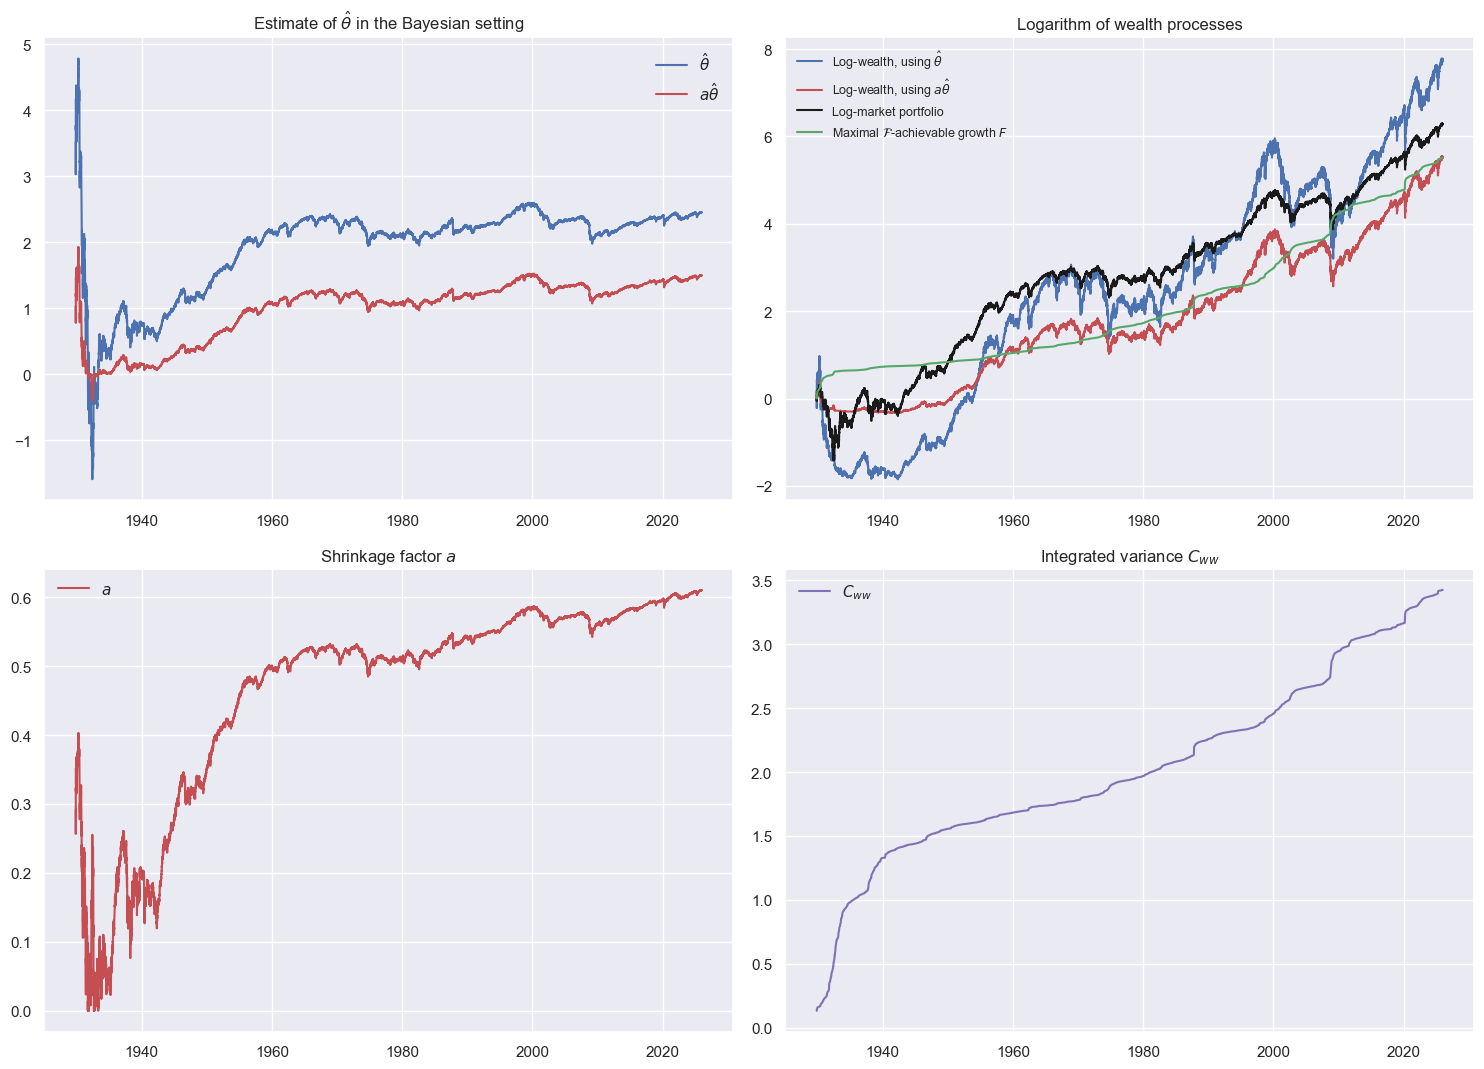

In [14]:
plot_panel(df, start_of_plot=idx_start, filename='US')

### Discretisation diagnostics reported in the paper

The following diagnostics compare exact daily compounding with the quadratic approximation corresponding to the continuous-time growth identity. They also verify positivity of all realised daily gross wealth factors and report the range of market exposures. The evaluation period is the same as for the figure above.

In [15]:
R = df['R'].iloc[idx_start:]
C = df['C'].iloc[idx_start:]

nuhat = R / C
sf = shrinkage_factor(nuhat, C)
r = df['disc_ret'].loc[nuhat.index]

portfolios = {
    'Unshrunk': nuhat.shift(1),
    'Shrunk': (nuhat * sf).shift(1),
}

rows = []

for name, pi in portfolios.items():
    x = (pi * r).dropna()
    pi = pi.loc[x.index]

    gross = 1 + x
    error = np.log(gross) - (x - 0.5 * x**2)

    rows.append({
        'Portfolio': name,
        'Terminal log-wealth discrepancy': abs(error.sum()),
        'Largest one-day discrepancy': error.abs().max(),
        'Date of largest discrepancy': error.abs().idxmax().date(),
        'Minimum gross wealth factor': gross.min(),
        'Date of minimum gross wealth factor': gross.idxmin().date(),
        'Minimum exposure': pi.min(),
        'Maximum exposure': pi.max(),
    })

pd.DataFrame(rows).set_index('Portfolio')

,Terminal log-wealth discrepancy,Largest one-day discrepancy,Date of largest discrepancy,Minimum gross wealth factor,Date of minimum gross wealth factor,Minimum exposure,Maximum exposure
Portfolio,,,,,,,
Unshrunk,0.075925,0.043848,1987-10-19,0.557620,1987-10-19,-1.594144,4.78515
Shrunk,0.009081,0.005526,1987-10-19,0.761467,1987-10-19,-0.406960,1.92825


### Performance statistics reported in the paper

Returns and wealth are discounted unless stated otherwise. The nominal CAGR
is computed from nominal wealth obtained by reinvesting at the risk-free rate.
Turnover is annualised one-way turnover under daily rebalancing and accounts
for the change in market exposure caused by the daily market return before
rebalancing.

In [16]:
performance_crsp = performance_statistics(df, start_of_plot=idx_start)
performance_crsp.round(2)

,Market,Unshrunk,Shrunk
"Annualised discounted log growth, $T^{-1}\log X_\pi(T)$, (%)",6.53,8.06,5.75
Nominal CAGR (%),10.15,11.84,9.28
Annualised volatility (%),18.15,33.20,17.35
Sharpe ratio,0.44,0.40,0.41
Maximum drawdown of discounted wealth (%),-82.21,-94.04,-72.83
"Terminal discounted wealth, $X_\pi(T)$",535.00,2313.53,250.44
Mean absolute market exposure,1.00,1.91,0.97
Annualised one-way turnover (%),0.00,540.69,109.08
"Terminal log wealth minus $F$, $\log X_\pi(T)-F(T)$",0.78,2.24,0.02


In [17]:
performance_crsp_latex = performance_crsp.copy()

performance_crsp_latex.columns = [
    r'Market $\market$',
    r'Unshrunk $\numf$',
    r'Shrunk $a\numf$',
]
performance_crsp_latex.index = (performance_crsp_latex.index.str.replace('%', r'\%', regex=False))

print(performance_crsp_latex.to_latex(float_format="%.2f", escape=False))

\begin{tabular}{lrrr}
\toprule
 & Market $\market$ & Unshrunk $\numf$ & Shrunk $a\numf$ \\
\midrule
Annualised discounted log growth, $T^{-1}\log X_\pi(T)$, (\%) & 6.53 & 8.06 & 5.75 \\
Nominal CAGR (\%) & 10.15 & 11.84 & 9.28 \\
Annualised volatility (\%) & 18.15 & 33.20 & 17.35 \\
Sharpe ratio & 0.44 & 0.40 & 0.41 \\
Maximum drawdown of discounted wealth (\%) & -82.21 & -94.04 & -72.83 \\
Terminal discounted wealth, $X_\pi(T)$ & 535.00 & 2313.53 & 250.44 \\
Mean absolute market exposure & 1.00 & 1.91 & 0.97 \\
Annualised one-way turnover (\%) & 0.00 & 540.69 & 109.08 \\
Terminal log wealth minus $F$, $\log X_\pi(T)-F(T)$ & 0.78 & 2.24 & 0.02 \\
\bottomrule
\end{tabular}

